# Porównanie metod aspektowej analizy sentymentu

Porównanie trzech metod predykcji w kontekście ABSA (Aspect-Based Sentiment Analysis):
- **Fine-tuned BERT** — douczony BERT na zbiorze etykietowanym ręcznie
- **Zero-shot (BART-MNLI)** — klasyfikacja zero-shot bez treningu na danych domenowych
- **LLM (GPT-4o-mini)** — duży model językowy ze structured output

Metodologia porównania wzorowana na *Gonçalves et al. „Comparing and combining sentiment analysis methods" (COSN 2013)*:
- **Prediction Performance** — Precision, Recall, F1, Accuracy *(cf. Table 5)*
- **F1 per aspekt** — skuteczność per aspekt *(cf. Table 6)*
- **Agreement** — zgodność między metodami *(cf. Table 4)*
- **Coverage** — odsetek aktywnych predykcji *(cf. Figure 1, 4)*
- **Macierze pomyłek** — rozkład błędów per klasa

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix,
)
from pathlib import Path

from config.global_config import TRAIN_ASPECTS, SENTIMENT_LABELS, ModelType
from predictions.predict_dataset import predict_dataset

ASPECTS = TRAIN_ASPECTS
LABELS = SENTIMENT_LABELS
CACHE_DIR = Path("statics/prediction_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 11, "font.size": 9})

def flat(df):
    """Spłaszcza aspekty z DataFrame do jednego wektora etykiet."""
    return np.concatenate([df[a].values for a in ASPECTS])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: mps


In [4]:
TEST_PATH = "statics/datasets/training.csv"

df = pd.read_csv(TEST_PATH)
for a in ASPECTS:
    df[a] = df[a].fillna("notmentioned")

gt = df[["text"] + ASPECTS].copy()
print(f"Zbiór: {len(gt)} recenzji × {len(ASPECTS)} aspektów = {len(gt) * len(ASPECTS)} etykiet\n")
gt[ASPECTS].apply(pd.Series.value_counts).T.fillna(0).astype(int).reindex(columns=LABELS)

Zbiór: 1000 recenzji × 8 aspektów = 8000 etykiet



,positive,neutral,negative,notmentioned
safety,48,41,66,845
cleanliness,48,33,48,871
infrastructure,61,36,52,851
nature,30,47,42,881
attractions,48,38,44,870
heritage,31,50,41,878
costs,61,31,49,859
other,84,44,44,828


In [13]:
METHODS = {
    "Fine-tuned BERT": ModelType.FINE_TUNED,
    "Zero-shot (BASE-BERT)": ModelType.ZERO_SHOT,
    # "LLM (GPT-4o-mini)": ModelType.LLM,  # odkomentuj jeśli OPENAI_API_KEY jest ustawiony
}

preds = {}
for name, mtype in METHODS.items():
    cache = CACHE_DIR / f"{mtype.value}.csv"
    if cache.exists():
        preds[name] = pd.read_csv(cache)
        print(f"✓ {name} (cache)")
    else:
        print(f"⏳ {name} — predykcja na {len(gt)} recenzjach...")
        tmp = gt[["text"]].copy()
        for a in ASPECTS:
            tmp[a] = "notmentioned"
        preds[name] = predict_dataset(tmp, mtype)
        preds[name].to_csv(cache, index=False)
        print(f"  ✓ zapisano cache → {cache}")

print(f"\nMetody do porównania: {list(preds.keys())}")

✓ Fine-tuned BERT (cache)
✓ Zero-shot (BASE-BERT) (cache)

Metody do porównania: ['Fine-tuned BERT', 'Zero-shot (BASE-BERT)']


## 0. Krzywe uczenia (Learning Curves)

Standardowa diagnostyka procesu treningu: krzywa strat (loss) i dokładności (accuracy) na zbiorze treningowym i walidacyjnym w funkcji epok. Pozwala ocenić konwergencję modelu oraz wykryć przeuczenie (overfitting) poprzez analizę luki generalizacyjnej (*generalization gap*) między zbiorami.

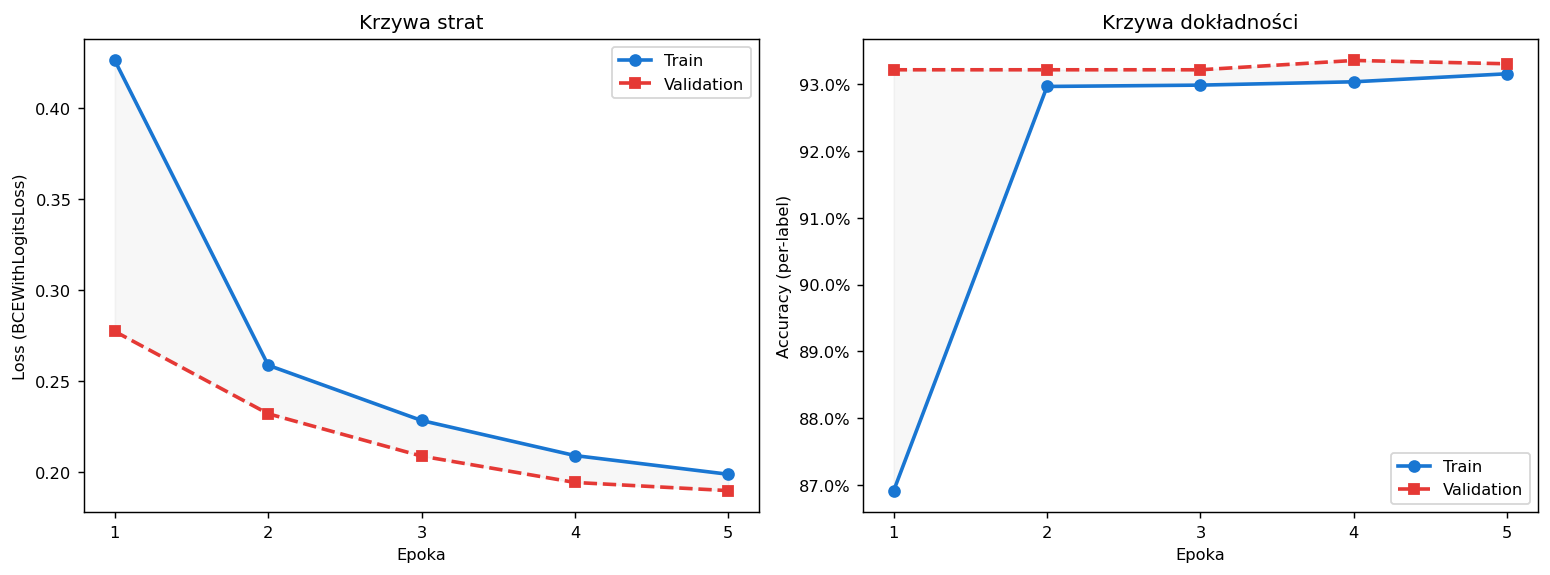

Najlepsza epoka (min val_loss): 5 — val_loss=0.1896, val_acc=0.9331
Luka generalizacyjna (epoka 5): Δloss=+0.0090, Δacc=-0.0015
→ Brak oznak przeuczenia (val_loss ≤ train_loss)


In [ ]:
import json

HISTORY_PATH = Path("statics/models/absa_1000/training_history.json")

if HISTORY_PATH.exists():
    with open(HISTORY_PATH) as f:
        history = json.load(f)
else:
    raise FileNotFoundError(f"File not found: {HISTORY_PATH}")

h = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))


ax1.plot(h["epoch"], h["train_loss"], "o-", label="Train", color="#1976D2", linewidth=2)
ax1.plot(h["epoch"], h["val_loss"], "s--", label="Validation", color="#E53935", linewidth=2)
ax1.fill_between(h["epoch"], h["train_loss"], h["val_loss"], alpha=0.08, color="#9E9E9E")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Loss (BCEWithLogitsLoss)")
ax1.set_title("Krzywa strat")
ax1.legend()
ax1.set_xticks(h["epoch"])

ax2.plot(h["epoch"], h["train_acc"], "o-", label="Train", color="#1976D2", linewidth=2)
ax2.plot(h["epoch"], h["val_acc"], "s--", label="Validation", color="#E53935", linewidth=2)
ax2.fill_between(h["epoch"], h["train_acc"], h["val_acc"], alpha=0.08, color="#9E9E9E")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy (per-label)")
ax2.set_title("Krzywa dokładności")
ax2.legend()
ax2.set_xticks(h["epoch"])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

gap_loss = h.iloc[-1]["train_loss"] - h.iloc[-1]["val_loss"]
gap_acc = h.iloc[-1]["train_acc"] - h.iloc[-1]["val_acc"]
best_val = h.loc[h["val_loss"].idxmin()]

print(f"Najlepsza epoka (min val_loss): {int(best_val['epoch'])} — val_loss={best_val['val_loss']:.4f}, val_acc={best_val['val_acc']:.4f}")
print(f"Luka generalizacyjna (epoka {int(h.iloc[-1]['epoch'])}): Δloss={gap_loss:+.4f}, Δacc={gap_acc:+.4f}")
print(f"{'→ Brak oznak przeuczenia (val_loss ≤ train_loss)' if gap_loss >= 0 else '→ Uwaga: możliwe przeuczenie'}")

## 1. Prediction Performance
*cf. Table 5 — Gonçalves et al. (2013)*

Metryki obliczone na łącznej puli etykiet (recenzja × aspekt), traktując każdy aspekt jako osobne zadanie klasyfikacji 4-klasowej (positive / neutral / negative / notmentioned).

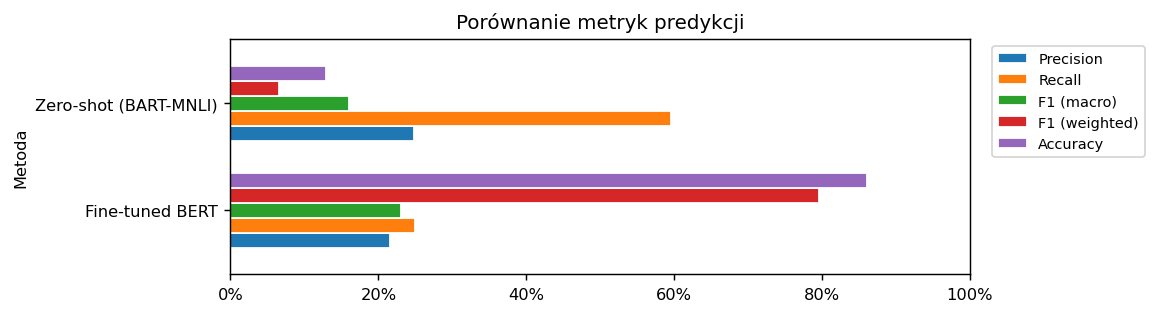

,Precision,Recall,F1 (macro),F1 (weighted),Accuracy
Metoda,,,,,
Fine-tuned BERT,0.215,0.250,0.231,0.796,0.860
Zero-shot (BART-MNLI),0.249,0.595,0.161,0.066,0.130


In [6]:
rows = []
for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    rows.append({
        "Metoda": name,
        "Precision": precision_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "Recall": recall_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "F1 (macro)": f1_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(yt, yp, labels=LABELS, average="weighted", zero_division=0),
        "Accuracy": accuracy_score(yt, yp),
    })

perf = pd.DataFrame(rows).set_index("Metoda")

fig, ax = plt.subplots(figsize=(9, max(len(preds) * 1.2, 2.5)))
perf.plot.barh(ax=ax, width=0.7, edgecolor="white")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Porównanie metryk predykcji")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

perf.style.format("{:.3f}").highlight_max(axis=0, props="background-color: #c8e6c9")

## 2. F1-score per aspekt
*cf. Table 6 — Gonçalves et al. (2013)*

F1 macro dla każdej kombinacji (metoda × aspekt) — pozwala zidentyfikować, które aspekty są najtrudniejsze dla poszczególnych metod.

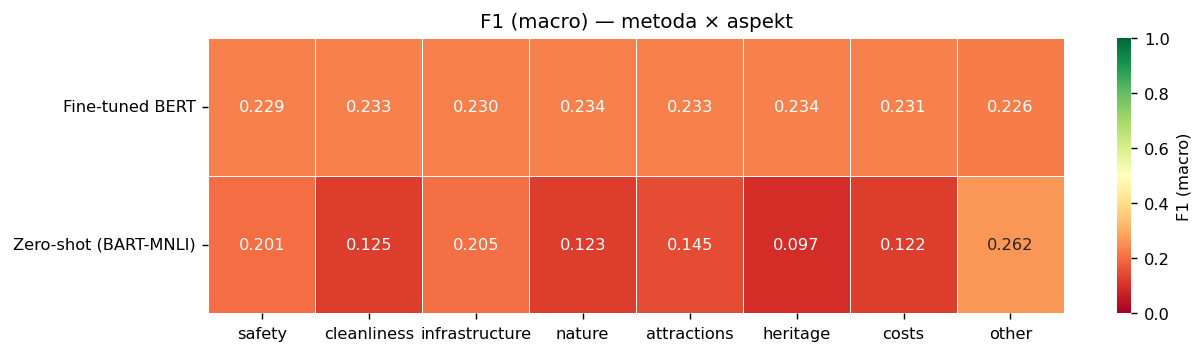

In [7]:
f1_asp = pd.DataFrame({
    name: {a: f1_score(gt[a], p[a], labels=LABELS, average="macro", zero_division=0)
           for a in ASPECTS}
    for name, p in preds.items()
}).T

fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.4, 2.5)))
sns.heatmap(
    f1_asp, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "F1 (macro)"},
)
ax.set_title("F1 (macro) — metoda × aspekt")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Agreement między metodami
*cf. Table 4 — Gonçalves et al. (2013)*

Odsetek par (recenzja × aspekt) dla których dwie metody przewidziały **identyczny** sentyment. Wysoka zgodność wzmacnia zaufanie do klasyfikacji; niska wskazuje, że metody interpretują tekst odmiennie.

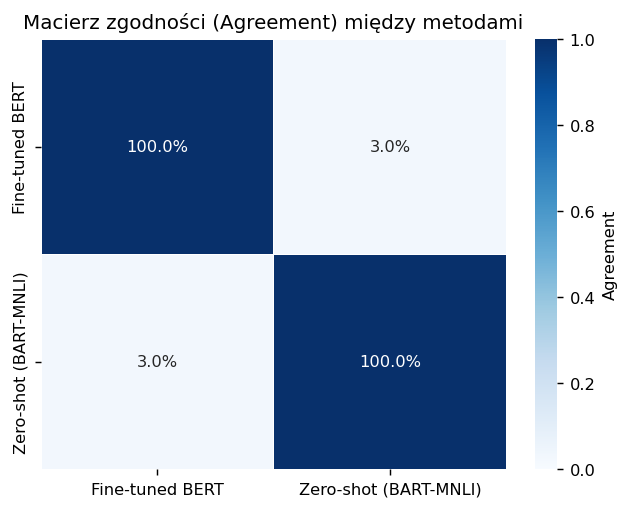

In [8]:
names = list(preds.keys())
agr = pd.DataFrame(
    [[(flat(preds[a]) == flat(preds[b])).mean() if i != j else 1.0
      for j, b in enumerate(names)]
     for i, a in enumerate(names)],
    index=names, columns=names,
)

fig, ax = plt.subplots(figsize=(max(len(names) * 2.5, 5), max(len(names) * 2, 4)))
sns.heatmap(
    agr, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Agreement"},
)
ax.set_title("Macierz zgodności (Agreement) między metodami")
plt.tight_layout()
plt.show()

## 4. Coverage
*cf. Figure 1 & Figure 4(a) — Gonçalves et al. (2013)*

Coverage = odsetek predykcji **różnych od `notmentioned`**. Niska wartość oznacza, że metoda nie wykrywa sentymentu i klasyfikuje większość par (recenzja × aspekt) jako niewspomniany. Jest to odpowiednik „fraction of messages whose sentiment is identified" z artykułu Gonçalves et al.

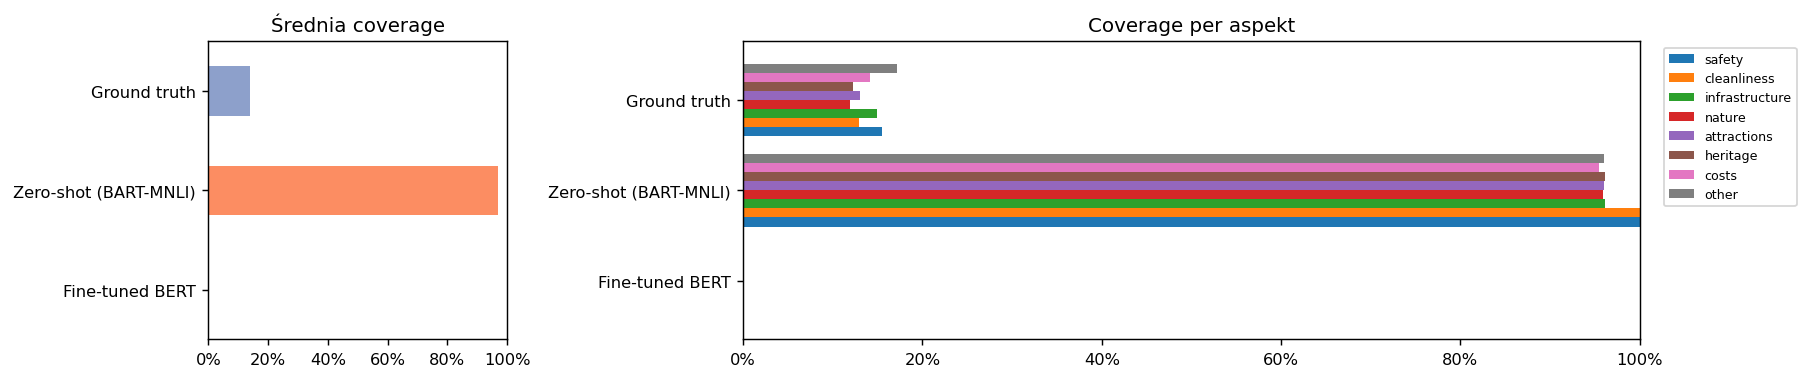

In [9]:
cov = pd.DataFrame(
    {n: {a: (p[a] != "notmentioned").mean() for a in ASPECTS} for n, p in preds.items()}
    | {"Ground truth": {a: (gt[a] != "notmentioned").mean() for a in ASPECTS}}
).T

fig, axes = plt.subplots(1, 2, figsize=(14, max(len(cov) * 1.0, 3)),
                          gridspec_kw={"width_ratios": [1, 3]})

cov.mean(axis=1).plot.barh(ax=axes[0], color=sns.color_palette("Set2", len(cov)))
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Średnia coverage")

cov.plot.barh(ax=axes[1], width=0.8)
axes[1].set_xlim(0, 1)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Coverage per aspekt")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

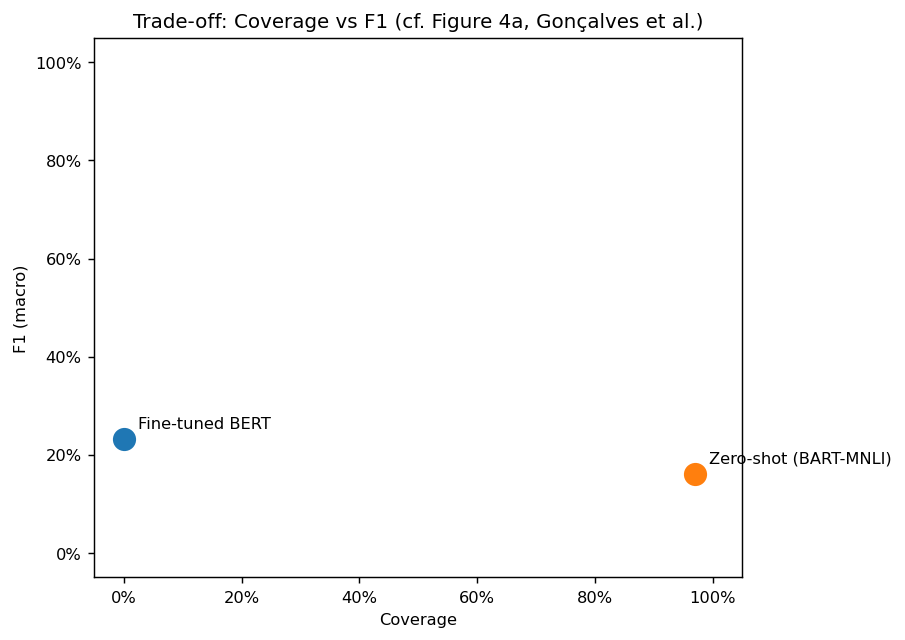

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in preds:
    yt, yp = flat(gt), flat(preds[name])
    f1 = f1_score(yt, yp, labels=LABELS, average="macro", zero_division=0)
    c = (yp != "notmentioned").mean()
    ax.scatter(c, f1, s=140, zorder=5)
    ax.annotate(name, (c, f1), textcoords="offset points", xytext=(8, 6), fontsize=9)

ax.set_xlabel("Coverage")
ax.set_ylabel("F1 (macro)")
ax.set_title("Trade-off: Coverage vs F1 (cf. Figure 4a, Gonçalves et al.)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## 5. Macierze pomyłek (Confusion Matrices)

Macierz pomyłek dla każdej metody, zagregowana po wszystkich aspektach. Kolory odpowiadają proporcji wierszowej (recall per klasa), liczby to wartości bezwzględne.

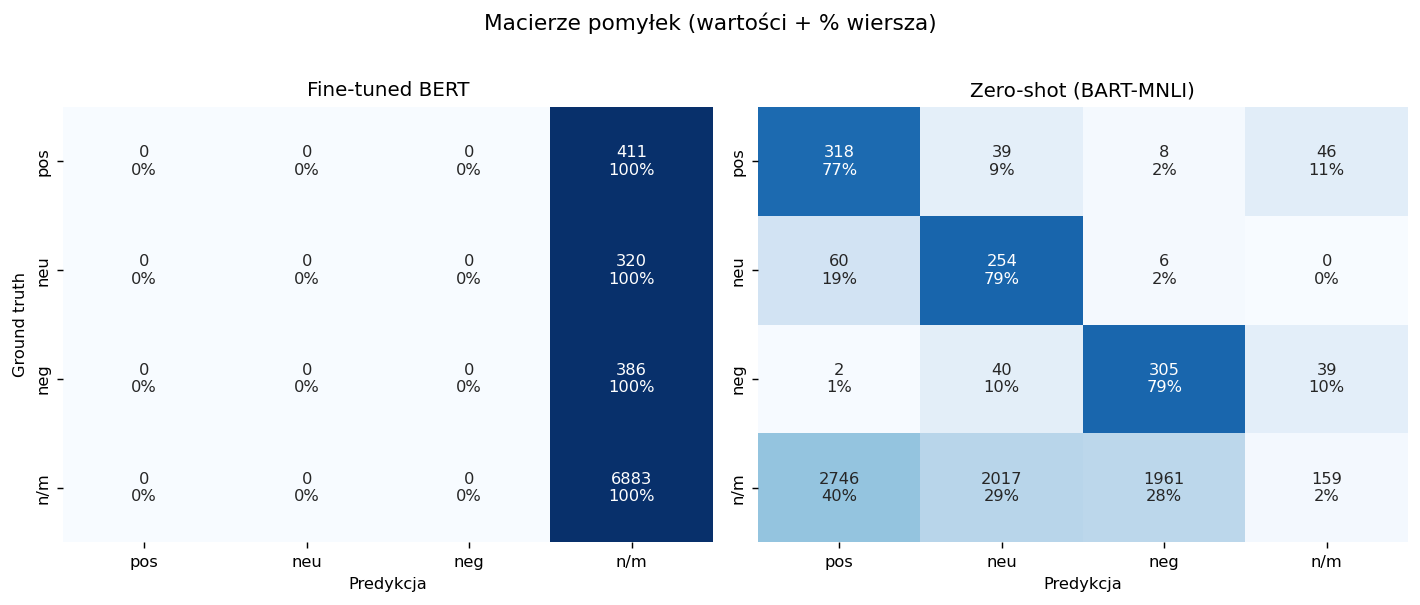

In [11]:
n_methods = len(preds)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 4.5))
if n_methods == 1:
    axes = [axes]

short = ["pos", "neu", "neg", "n/m"]

for ax, (name, p) in zip(axes, preds.items()):
    yt, yp = flat(gt), flat(p)
    cm = confusion_matrix(yt, yp, labels=LABELS)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm / row_sums

    annot = np.array([
        [f"{v}\n{pct:.0%}" for v, pct in zip(r, rn)]
        for r, rn in zip(cm, cm_norm)
    ])

    sns.heatmap(
        cm_norm, annot=annot, fmt="", cmap="Blues",
        xticklabels=short, yticklabels=short,
        ax=ax, vmin=0, vmax=1, cbar=False,
    )
    ax.set_title(name)
    ax.set_ylabel("Ground truth" if ax is axes[0] else "")
    ax.set_xlabel("Predykcja")

plt.suptitle("Macierze pomyłek (wartości + % wiersza)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()